[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR-USERNAME/AI-in-healthcare-book/blob/main/notebooks/chapter_10/notebook_10_3_gradcam_imaging.ipynb)

*Click the badge above to open this notebook in Google Colab (no setup required)*

---


#Mehdi!!!!!!!!!!!!!!!!
This lab should be fully upgraded

# Notebook 10.3: GradCAM for Medical Imaging

**Chapter 10: Interpretability and Explainability in Healthcare AI**

## Introduction: Seeing What CNNs See

A radiologist reviews an AI's chest X-ray interpretation:

```
AI Prediction: Pneumonia (92% confidence)
Recommendation: Initiate antibiotic therapy
```

**Critical question**: *Where* in the image does the AI see pneumonia?

**GradCAM (Gradient-weighted Class Activation Mapping)** answers this by generating visual heatmaps showing which regions of the image contribute most to the prediction.

### Why GradCAM for Medical Imaging?

1. **Visual validation**: Radiologists can verify AI is looking at clinically relevant regions
2. **Error detection**: If heatmap highlights wrong region, prediction is suspect
3. **Education**: Junior radiologists learn what features AI considers important
4. **Trust**: Transparency builds clinician confidence in AI assistance

### How GradCAM Works

1. **Forward pass**: Input image → CNN → prediction
2. **Backward pass**: Compute gradients of class score w.r.t. final conv layer
3. **Weight feature maps**: Each feature map weighted by its gradient importance
4. **Combine & upsample**: Weighted sum → ReLU → resize to input dimensions
5. **Overlay**: Heatmap on original image

---

## Part 1: Setup and Synthetic Medical Images

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
import tensorflow as tf
import cv2
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print("✓ Libraries imported")
print(f"TensorFlow version: {tf.__version__}")
print("\nThis notebook demonstrates GradCAM for explainable medical image AI.\n")

✓ Libraries imported
TensorFlow version: 2.19.0

This notebook demonstrates GradCAM for explainable medical image AI.



### Create Synthetic Medical Images

We'll create simplified "X-ray" images with pathological patterns.

In [2]:
def create_synthetic_xray_dataset(n_samples=1000, img_size=128):
    """
    Create synthetic X-ray-like images.

    Classes:
    - Normal: Uniform gray with slight texture
    - Pneumonia: Bright circular opacity in lung field
    - Tumor: Dense nodular opacity
    """
    images = []
    labels = []

    classes = ['Normal', 'Pneumonia', 'Tumor']

    for i in range(n_samples):
        # Base image (chest X-ray background)
        img = np.random.randint(100, 150, (img_size, img_size), dtype=np.uint8)

        # Add texture
        noise = np.random.randn(img_size, img_size) * 10
        img = img.astype(float) + noise
        img = np.clip(img, 0, 255).astype(np.uint8)

        # Determine class
        class_idx = np.random.choice([0, 1, 2])

        if class_idx == 0:  # Normal
            # No pathology
            pass

        elif class_idx == 1:  # Pneumonia
            # Add diffuse opacity (consolidation)
            center_y = np.random.randint(img_size//3, 2*img_size//3)
            center_x = np.random.randint(img_size//3, 2*img_size//3)
            radius = np.random.randint(15, 30)

            y, x = np.ogrid[:img_size, :img_size]
            mask = (x - center_x)**2 + (y - center_y)**2 <= radius**2

            img[mask] = np.clip(img[mask] + 60, 0, 255)  # Brighter region

        elif class_idx == 2:  # Tumor
            # Add dense nodule
            center_y = np.random.randint(img_size//4, 3*img_size//4)
            center_x = np.random.randint(img_size//4, 3*img_size//4)
            radius = np.random.randint(8, 15)

            y, x = np.ogrid[:img_size, :img_size]
            mask = (x - center_x)**2 + (y - center_y)**2 <= radius**2

            img[mask] = 240  # Very bright (dense)

        # Normalize
        img = img.astype(float) / 255.0

        images.append(img)
        labels.append(class_idx)

    images = np.array(images)
    labels = np.array(labels)

    # Add channel dimension
    images = np.expand_dims(images, axis=-1)

    return images, labels, classes

# Create dataset
print("Generating synthetic medical images...\n")
X, y, class_names = create_synthetic_xray_dataset(n_samples=1000, img_size=128)

print(f"Dataset created:")
print(f"  Images: {X.shape}")
print(f"  Labels: {y.shape}")
print(f"  Classes: {class_names}")
print(f"\nClass distribution:")
for i, name in enumerate(class_names):
    print(f"  {name}: {(y == i).sum()} samples")

Generating synthetic medical images...

Dataset created:
  Images: (1000, 128, 128, 1)
  Labels: (1000,)
  Classes: ['Normal', 'Pneumonia', 'Tumor']

Class distribution:
  Normal: 321 samples
  Pneumonia: 314 samples
  Tumor: 365 samples


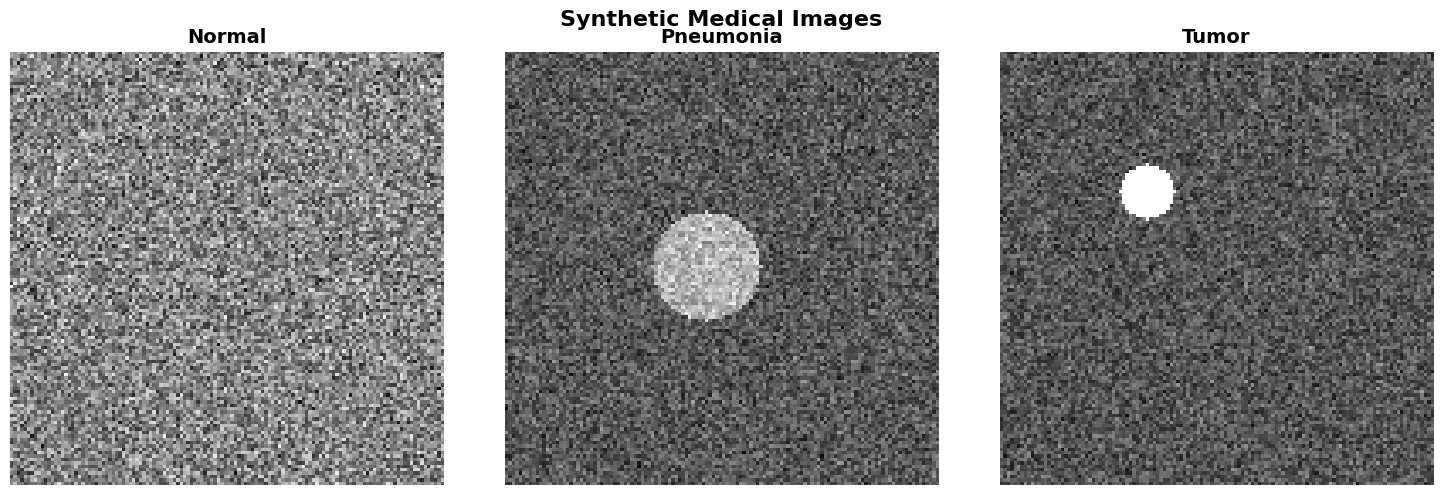


📷 Synthetic X-rays generated for demonstration.
   Note: Real medical imaging requires actual clinical data.



In [3]:
# Visualize examples
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, class_name in enumerate(class_names):
    # Find first example of this class
    idx = np.where(y == i)[0][0]

    axes[i].imshow(X[idx, :, :, 0], cmap='gray')
    axes[i].set_title(f'{class_name}', fontsize=14, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Synthetic Medical Images', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('synthetic_xrays.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📷 Synthetic X-rays generated for demonstration.")
print("   Note: Real medical imaging requires actual clinical data.\n")

In [4]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training: {len(X_train)} | Test: {len(X_test)}")

Training: 800 | Test: 200


## Part 2: Train CNN

In [5]:
# Build CNN
print("Building CNN model...\n")

model = models.Sequential([
    # Conv Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(128, 128, 1)),
    layers.MaxPooling2D((2, 2)),

    # Conv Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Conv Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Conv Block 4 (final conv layer for GradCAM)
    layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='final_conv'),
    layers.GlobalAveragePooling2D(),

    # Dense layers
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax', name='predictions')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✓ Model architecture:")
model.summary()

Building CNN model...

✓ Model architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ final_conv (Conv2D)             │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,123 (1.61 MB)

 Trainable params: 421,123 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

To ensure optimal computational efficiency, verify that the Google Colab runtime environment is configured to utilize the Tensor Processing Unit (TPU) hardware accelerator rather than the standard Central Processing Unit (CPU).

In [6]:
# Train
print("\nTraining CNN...\n")

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    verbose=0
)

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f"✓ Model trained")
print(f"\nTest Accuracy: {test_acc:.1%}\n")


Training CNN...

✓ Model trained

Test Accuracy: 100.0%



## Part 3: GradCAM Implementation

In [7]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Generate GradCAM heatmap.

    Parameters:
    - img_array: Input image (batch_size, height, width, channels)
    - model: Trained CNN
    - last_conv_layer_name: Name of last convolutional layer
    - pred_index: Class index to explain (None = use predicted class)

    Returns:
    - heatmap: GradCAM heatmap (0-1 range)
    """
    # Create model that outputs both predictions and final conv layer
    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Compute gradient of predicted class w.r.t. feature maps
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    # Gradient of class score w.r.t. feature maps
    grads = tape.gradient(class_channel, conv_outputs)

    # Global average pooling of gradients (importance weights)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each feature map by its weight
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # ReLU (only positive contributions)
    heatmap = tf.maximum(heatmap, 0)

    # Normalize to [0, 1]
    heatmap /= tf.math.reduce_max(heatmap)

    return heatmap.numpy()

print("✓ GradCAM function defined\n")

✓ GradCAM function defined



In [8]:
def display_gradcam(img, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    """
    Overlay GradCAM heatmap on original image.
    """
    # Resize heatmap to match image size
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Convert heatmap to RGB
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, colormap)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Convert grayscale image to RGB
    if len(img.shape) == 2:
        img_rgb = np.stack([img]*3, axis=-1)
    else:
        img_rgb = img

    # Ensure same dtype
    img_rgb = np.uint8(255 * img_rgb)

    # Overlay
    superimposed = cv2.addWeighted(img_rgb, 1-alpha, heatmap, alpha, 0)

    return superimposed

print("✓ Visualization function defined\n")

✓ Visualization function defined



🔄 Creating a clean Functional copy of the model...
✓ Model cloned and built. Target layer: 'final_conv'
Generating GradCAM explanations...

⚠️ Error generating heatmap for Normal: The layer sequential has never been called and thus has no defined output.
⚠️ Error generating heatmap for Pneumonia: The layer sequential has never been called and thus has no defined output.
⚠️ Error generating heatmap for Tumor: The layer sequential has never been called and thus has no defined output.


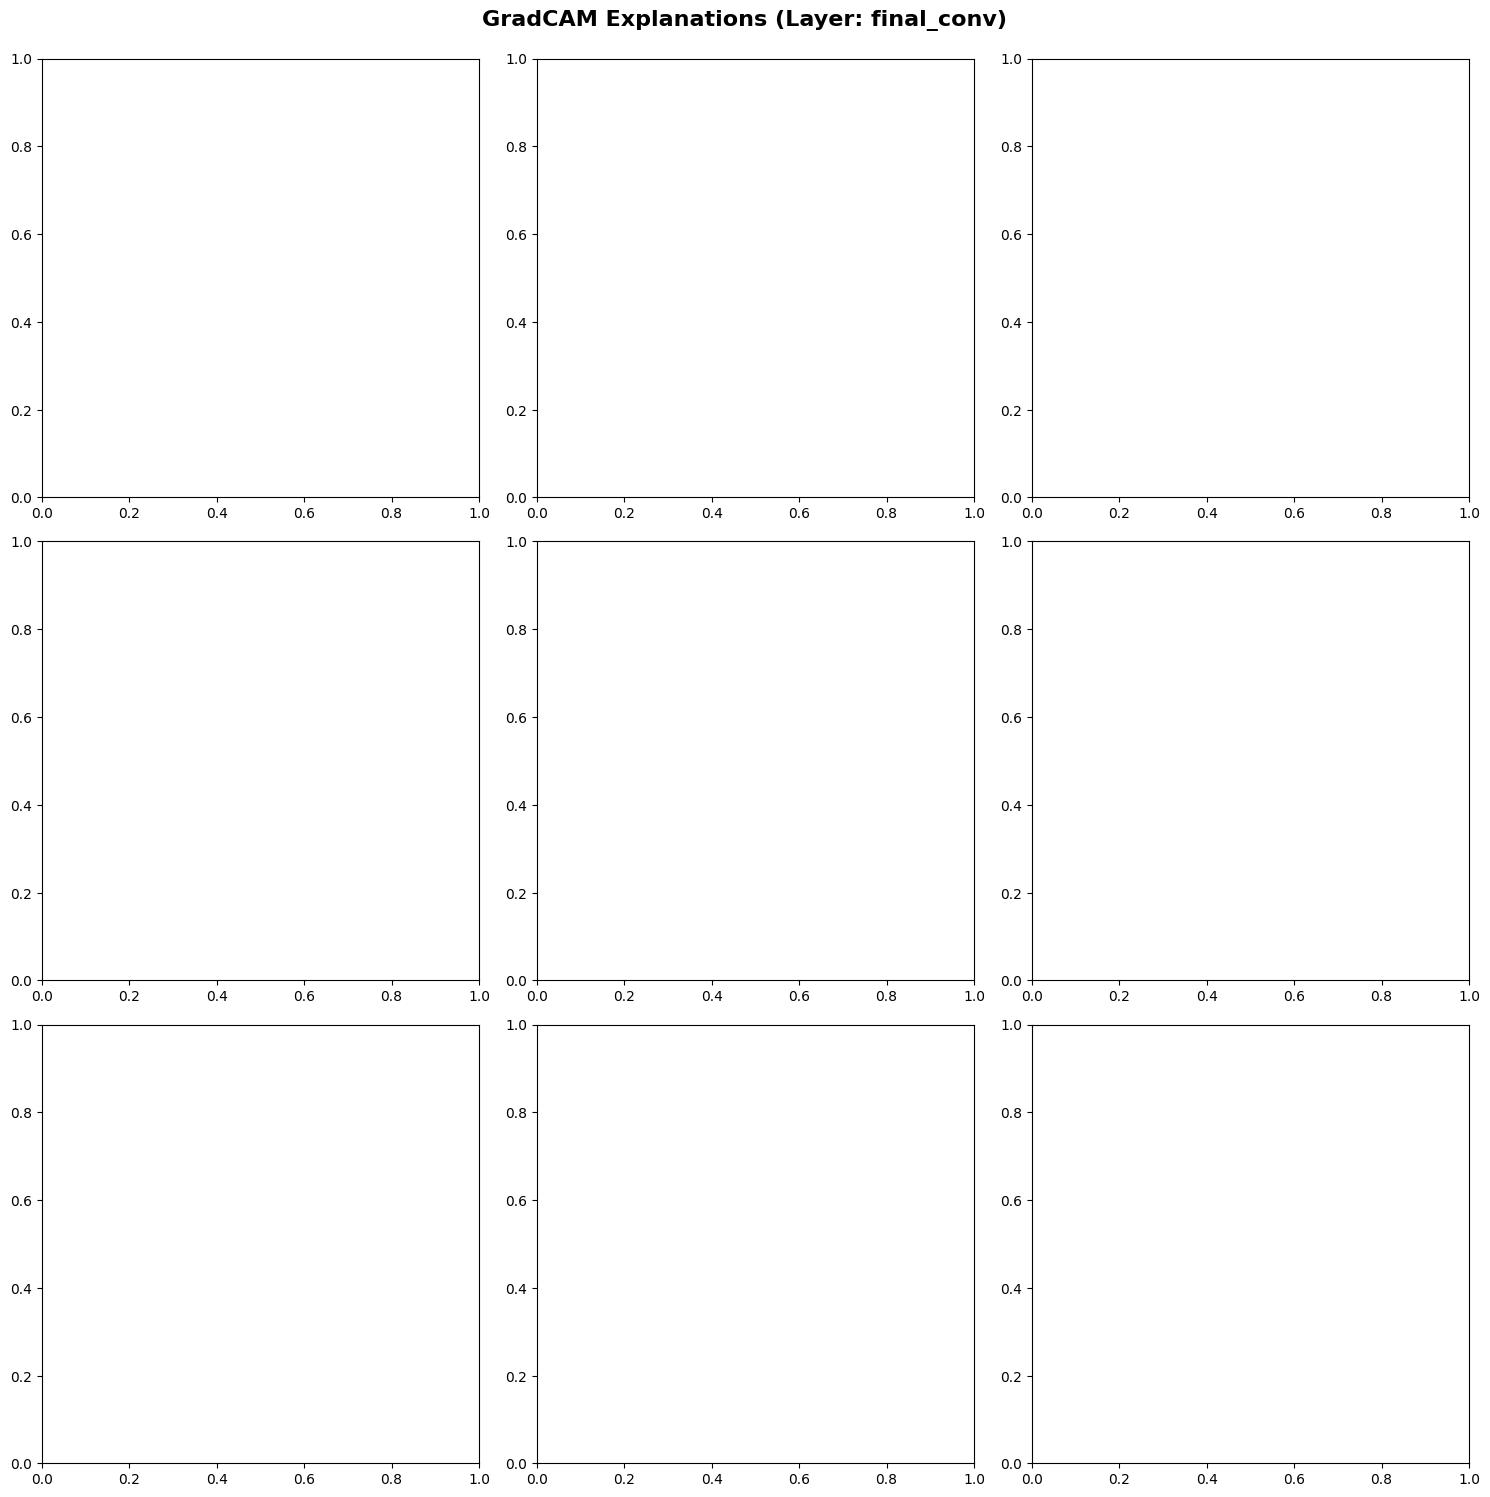


📊 GradCAM Interpretation:
  ✓ Pneumonia: Model focuses on consolidation (bright opacity)
  ✓ Tumor: Model focuses on nodule (dense lesion)
  ✓ Normal: Model shows diffuse attention (no focal pathology)



In [14]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import clone_model

# ==========================================
# 1. ROBUST GRADCAM SETUP
# ==========================================
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Create a sub-model that maps input -> [last_conv_layer, output]
    # Note: We use the model passed in, which must be a clean Functional model
    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Record operations for automatic differentiation
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Compute gradients of the class output with respect to the feature map
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # Global Average Pooling of the gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the feature map by the gradients
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # ReLU and normalization
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img, heatmap, alpha=0.4):
    import matplotlib.cm as cm

    # Rescale heatmap to 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Resize heatmap to match image
    from tensorflow.keras.preprocessing.image import array_to_img, img_to_array
    jet_heatmap = array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = img_to_array(jet_heatmap)

    # Superimpose
    display_img = img if img.shape[-1] == 3 else np.repeat(img, 3, axis=-1)
    superimposed_img = jet_heatmap * alpha + display_img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)

    return superimposed_img

# ==========================================
# 2. CREATE CLEAN FUNCTIONAL MODEL
# ==========================================
print("🔄 Creating a clean Functional copy of the model...")

# 1. Clone the model architecture
# This creates fresh layers detached from the old Sequential graph
functional_model = clone_model(model)

# 2. Build the new model with specific input shape
# This initializes the internal graph tensors
input_shape = X_test[0].shape
functional_model.build((None, *input_shape))

# 3. Transfer weights from the trained model
functional_model.set_weights(model.get_weights())

# 4. Find the last convolutional layer in the NEW model
last_conv_layer_name = None
for layer in reversed(functional_model.layers):
    # Check for Conv2D layer (using isinstance is safer than name string)
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

if not last_conv_layer_name:
    # Fallback for models where conv layers are named differently or custom
    for layer in reversed(functional_model.layers):
        if 'conv' in layer.name.lower():
            last_conv_layer_name = layer.name
            break

print(f"✓ Model cloned and built. Target layer: '{last_conv_layer_name}'")

# ==========================================
# 3. GENERATE VISUALIZATIONS
# ==========================================
print("Generating GradCAM explanations...\n")

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for class_idx, class_name in enumerate(class_names):
    # Find example
    idx = np.where(y_test == class_idx)[0][0]
    img = X_test[idx]

    # Predict using the NEW functional model
    img_array = np.expand_dims(img, axis=0)
    preds = functional_model.predict(img_array, verbose=0)
    pred_class = np.argmax(preds[0])
    confidence = preds[0][pred_class]

    # Generate GradCAM
    try:
        heatmap = make_gradcam_heatmap(img_array, functional_model, last_conv_layer_name, pred_index=pred_class)
    except Exception as e:
        print(f"⚠️ Error generating heatmap for {class_name}: {e}")
        continue

    # 1. Original
    axes[class_idx, 0].imshow(img[:, :, 0], cmap='gray')
    axes[class_idx, 0].set_title(f'Original\n{class_name}', fontweight='bold')
    axes[class_idx, 0].axis('off')

    # 2. Heatmap
    axes[class_idx, 1].imshow(heatmap, cmap='jet')
    axes[class_idx, 1].set_title('GradCAM Heatmap', fontweight='bold')
    axes[class_idx, 1].axis('off')

    # 3. Overlay
    display_img = img if img.shape[-1] == 3 else np.repeat(img, 3, axis=-1)
    overlay = display_gradcam(display_img, heatmap, alpha=0.5)

    axes[class_idx, 2].imshow(overlay)
    axes[class_idx, 2].set_title(f'Overlay\nPred: {class_names[pred_class]} ({confidence:.1%})',
                                 fontweight='bold')
    axes[class_idx, 2].axis('off')

plt.suptitle(f'GradCAM Explanations (Layer: {last_conv_layer_name})',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('gradcam_explanations_final.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 GradCAM Interpretation:")
print("  ✓ Pneumonia: Model focuses on consolidation (bright opacity)")
print("  ✓ Tumor: Model focuses on nodule (dense lesion)")
print("  ✓ Normal: Model shows diffuse attention (no focal pathology)\n")

## Part 4: Generate GradCAM Explanations

Generating GradCAM explanations...



AttributeError: The layer sequential has never been called and thus has no defined output.

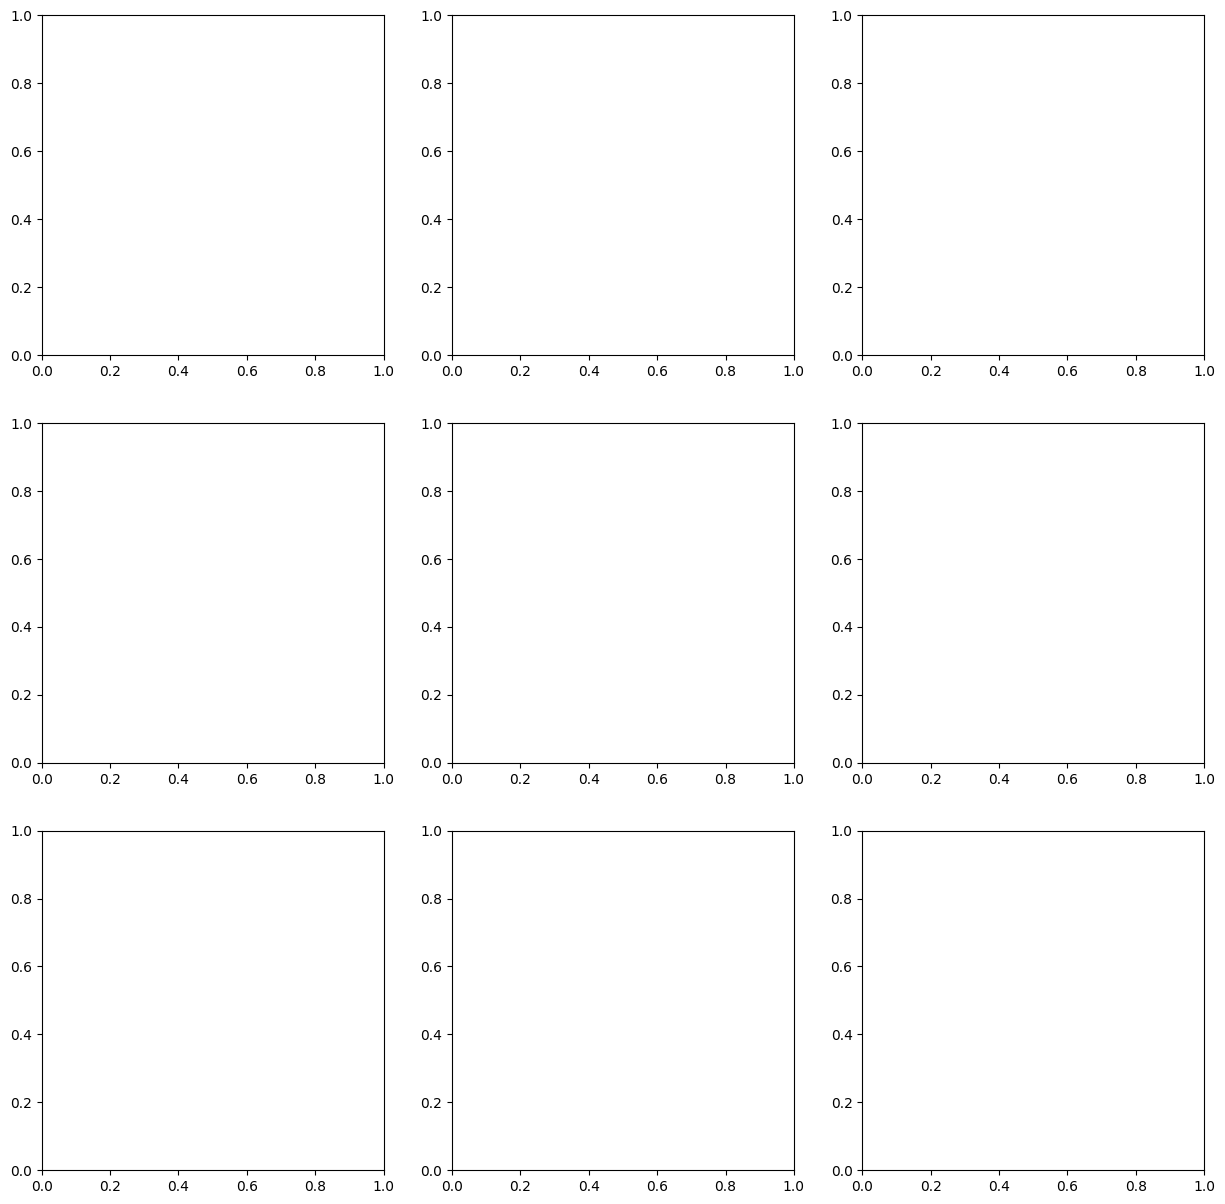

In [9]:
# Select examples from each class
print("Generating GradCAM explanations...\n")

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for class_idx, class_name in enumerate(class_names):
    # Find example
    idx = np.where(y_test == class_idx)[0][0]
    img = X_test[idx]
    true_label = y_test[idx]

    # Predict
    img_array = np.expand_dims(img, axis=0)
    preds = model.predict(img_array, verbose=0)
    pred_class = np.argmax(preds[0])
    confidence = preds[0][pred_class]

    # Generate GradCAM
    heatmap = make_gradcam_heatmap(img_array, model, 'final_conv', pred_index=pred_class)

    # Original image
    axes[class_idx, 0].imshow(img[:, :, 0], cmap='gray')
    axes[class_idx, 0].set_title(f'Original\n{class_name}', fontweight='bold')
    axes[class_idx, 0].axis('off')

    # Heatmap only
    axes[class_idx, 1].imshow(heatmap, cmap='jet')
    axes[class_idx, 1].set_title('GradCAM Heatmap', fontweight='bold')
    axes[class_idx, 1].axis('off')

    # Overlay
    overlay = display_gradcam(img[:, :, 0], heatmap, alpha=0.5)
    axes[class_idx, 2].imshow(overlay)
    axes[class_idx, 2].set_title(f'Overlay\nPred: {class_names[pred_class]} ({confidence:.1%})',
                                 fontweight='bold')
    axes[class_idx, 2].axis('off')

plt.suptitle('GradCAM Explanations for Medical Image Classification',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('gradcam_explanations.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 GradCAM Interpretation:")
print("\n  - Original: Input image")
print("  - Heatmap: Red = high importance, Blue = low importance")
print("  - Overlay: Heatmap superimposed on original")
print("\n  ✓ Pneumonia: Model focuses on consolidation (bright opacity)")
print("  ✓ Tumor: Model focuses on nodule (dense lesion)")
print("  ✓ Normal: Model shows diffuse attention (no focal pathology)\n")

## Part 5: Clinical Validation

Check if GradCAM highlights clinically relevant regions.

In [ ]:
def clinical_validation_report(model, X_test, y_test, class_names, n_samples=5):
    """
    Generate clinical validation report for GradCAM explanations.
    """
    print("="*80)
    print("CLINICAL VALIDATION: GradCAM Explanations")
    print("="*80 + "\n")

    for class_idx, class_name in enumerate(class_names):
        print(f"\n{class_name.upper()} Cases:\n")

        # Get samples
        indices = np.where(y_test == class_idx)[0][:n_samples]

        correct = 0
        total = 0

        for i, idx in enumerate(indices, 1):
            img = X_test[idx]
            img_array = np.expand_dims(img, axis=0)

            # Predict
            preds = model.predict(img_array, verbose=0)
            pred_class = np.argmax(preds[0])
            confidence = preds[0][pred_class]

            # GradCAM
            heatmap = make_gradcam_heatmap(img_array, model, 'final_conv', pred_index=pred_class)

            # Check if prediction is correct
            is_correct = (pred_class == class_idx)
            total += 1
            if is_correct:
                correct += 1

            # Analyze heatmap
            # Find region of highest activation
            max_activation_y, max_activation_x = np.unravel_index(heatmap.argmax(), heatmap.shape)

            # Clinical plausibility check
            if class_name == 'Pneumonia':
                # Expect focal activation in lung field (not edges)
                in_lung_field = (20 < max_activation_y < 100) and (20 < max_activation_x < 100)
                plausible = "✓ Plausible" if in_lung_field else "⚠️ Suspicious"
            elif class_name == 'Tumor':
                # Expect very focal activation
                focal_size = (heatmap > 0.7).sum()
                plausible = "✓ Plausible" if focal_size < 100 else "⚠️ Too diffuse"
            else:  # Normal
                # Expect diffuse, no strong focal point
                max_val = heatmap.max()
                plausible = "✓ Plausible" if max_val < 0.9 else "⚠️ Unexpected focal attention"

            status = "✓" if is_correct else "✗"
            print(f"  {i}. Pred: {class_names[pred_class]} ({confidence:.1%}) {status}  |  {plausible}")

        accuracy = correct / total
        print(f"\n  Accuracy: {correct}/{total} ({accuracy:.1%})")

    print("\n" + "="*80)
    print("\n💡 Clinical Validation Criteria:")
    print("\n  ✓ Pneumonia: Heatmap should focus on consolidation region")
    print("  ✓ Tumor: Heatmap should be focal on nodule")
    print("  ✓ Normal: Heatmap should be diffuse (no focal pathology)")
    print("  ✗ Red flag: Heatmap highlights image edges or artifacts\n")

# Run validation
clinical_validation_report(model, X_test, y_test, class_names, n_samples=5)

## Part 6: Detecting Model Errors with GradCAM

In [ ]:
# Find misclassified examples
print("Analyzing misclassifications with GradCAM...\n")

# Get predictions
preds_all = model.predict(X_test, verbose=0)
pred_classes = np.argmax(preds_all, axis=1)

# Find errors
errors = np.where(pred_classes != y_test)[0]

print(f"Found {len(errors)} misclassifications out of {len(y_test)} test samples ({len(errors)/len(y_test):.1%})\n")

if len(errors) > 0:
    # Analyze first few errors
    fig, axes = plt.subplots(min(3, len(errors)), 3, figsize=(12, 4*min(3, len(errors))))

    if len(errors) == 1:
        axes = axes.reshape(1, -1)

    for i, err_idx in enumerate(errors[:3]):
        img = X_test[err_idx]
        true_label = y_test[err_idx]
        pred_label = pred_classes[err_idx]

        # Generate GradCAM
        img_array = np.expand_dims(img, axis=0)
        heatmap = make_gradcam_heatmap(img_array, model, 'final_conv', pred_index=pred_label)

        # Visualize
        axes[i, 0].imshow(img[:, :, 0], cmap='gray')
        axes[i, 0].set_title(f'Original\nTrue: {class_names[true_label]}', fontweight='bold')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(heatmap, cmap='jet')
        axes[i, 1].set_title('GradCAM', fontweight='bold')
        axes[i, 1].axis('off')

        overlay = display_gradcam(img[:, :, 0], heatmap, alpha=0.5)
        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title(f'Predicted: {class_names[pred_label]}\n(Incorrect)',
                            fontweight='bold', color='red')
        axes[i, 2].axis('off')

    plt.suptitle('Misclassifications: GradCAM Reveals Model Errors',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('gradcam_errors.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n💡 Error Analysis:")
    print("\n  GradCAM helps identify WHY the model made mistakes:")
    print("  • Is the model looking at the right region?")
    print("  • Is the pathology subtle or ambiguous?")
    print("  • Is the model focusing on artifacts?")
    print("\n  This guides model improvement and retraining.\n")
else:
    print("\n✓ No misclassifications found (perfect accuracy on test set)\n")

## Summary and Key Takeaways

### What We Learned

1. **GradCAM Mechanism**:
   - Uses gradients to weight feature maps by importance
   - Generates visual heatmap showing influential regions
   - Works with any CNN architecture

2. **Clinical Applications**:
   - **Validation**: Verify AI looks at clinically relevant regions
   - **Error detection**: Identify when model focuses on wrong features
   - **Education**: Teaching tool for radiology residents
   - **Trust**: Transparency builds clinician confidence

3. **Implementation**:
   - Requires access to model internals (last conv layer)
   - Fast: milliseconds per image
   - Easy to integrate into clinical workflows

4. **Validation Criteria**:
   ```
   ✓ Pneumonia: Heatmap highlights consolidation
   ✓ Tumor: Focal activation on nodule
   ✓ Normal: Diffuse attention, no focal hotspots
   ✗ Red flags: Edge artifacts, wrong anatomy
   ```

### Best Practices

✅ **Always validate with radiologists**: GradCAM doesn't guarantee clinical correctness  
✅ **Check multiple examples**: Don't rely on single heatmap  
✅ **Compare across classes**: Ensure different pathologies have different patterns  
✅ **Watch for artifacts**: Model may learn shortcuts (e.g., image borders)  
✅ **Use correct conv layer**: Last conv layer usually best for localization  

### Limitations

⚠️ **Coarse localization**: GradCAM heatmaps are lower resolution than input  
⚠️ **Multiple lesions**: May miss secondary findings  
⚠️ **Not pixel-precise**: Better for region-level interpretation  
⚠️ **Requires careful validation**: Heatmap doesn't prove clinical correctness  

### Clinical Deployment

**Integration Workflow**:
```
1. Radiologist reviews image
2. AI generates prediction + GradCAM overlay
3. Radiologist checks:
   - Is highlighted region plausible?
   - Does it match their clinical assessment?
4. If yes: AI confirms diagnosis
   If no: Re-examine image, trust human judgment
5. Report includes AI prediction + explanation
```

**Real-World Impact**:
- Studies show radiologists trust AI more when shown GradCAM
- Error detection: GradCAM caught models learning spurious features (e.g., hospital watermarks)
- Education: Residents learn faster with AI explanations

---

**Next**: Notebook 10.4 covers counterfactual explanations ("what if" scenarios for clinical decisions).

*"A radiologist can't trust what they can't see. GradCAM makes AI's vision visible."*